In [1]:
import os
import math
import h5py
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader as TorchDataLoader
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import EdgeConv, SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.utils import degree, to_networkx, to_undirected

/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [5]:
FILE_PATH = "datasets/quark-gluon_data-set_n139306.hdf5"
MAIN_K = 8
MAIN_CACHE_FILE = f"qg_graph_dataset_k{MAIN_K}_edgeattr.pt"

# set division
VAL_SIZE = 0.15
TEST_SIZE = 0.15

BATCH_SIZE = 6

EPOCHS = 20
BASELINE_EPOCHS = 8

lr = 3e-3
WEIGHT_DECAY = 1e-4

DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [6]:
with h5py.File(FILE_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    X = f["X_jets"][:]
    y = np.asarray(f["y"][:]).reshape(-1).astype(np.int64)
    pt = np.asarray(f["pt"][:]).reshape(-1).astype(np.float32)
    m0 = np.asarray(f["m0"][:]).reshape(-1).astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("pt shape:", pt.shape)
print("m0 shape:", m0.shape)

unique, counts = np.unique(y, return_counts=True)
print("Class counts:", dict(zip(unique.tolist(), counts.tolist())))

Keys: ['X_jets', 'm0', 'pt', 'y']
X shape: (139306, 125, 125, 3)
y shape: (139306,)
pt shape: (139306,)
m0 shape: (139306,)
Class counts: {0: 69653, 1: 69653}


class are equaly proportional = 50% each
# EDA

In [8]:
# variation of pt and m0
# for note (and learning): pt is transverse momentum and m0 is invariant mass
print(pt.min(), pt.max(), pt.mean())
print(m0.min(), m0.max(), m0.mean())

70.11005 337.05173 117.12393
3.3729308 75.95049 21.39222


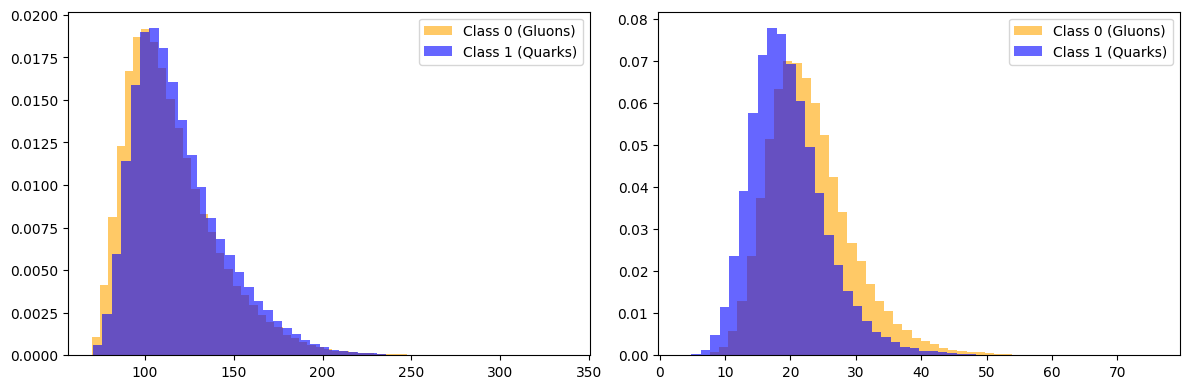

In [ ]:
def plot_pt_m0(pt, m0, y):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    ax.hist(pt[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(pt[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()

    ax[1].hist(m0[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax[1].hist(m0[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_pt_m0(pt, m0, y)

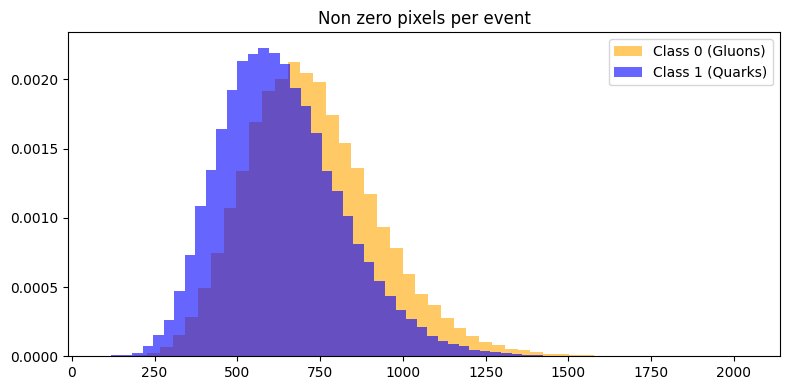

Gluon — mean: 727.9 | median: 709.0
Quark — mean: 634.6 | median: 616.0
Sparsity - Gluon — mean: 0.9534 | median: 0.9546
Sparsity - Quark — mean: 0.9594 | median: 0.9606


In [37]:
def to_hwc(image):
    image = np.asarray(image)

    if image.ndim == 2:
        return image[..., None]
    if image.ndim != 3:
        raise ValueError(f'Unexpected image shape: {image.shape}')
    
    if image.shape[0] <= 6 and image.shape[1] > 6 and image.shape[2] > 6:
        image. np.transpose(image, (1,2,0))
    return image

def plot_nonzero(X, y):
    non_zero_counts = []
    sparsity = []
    for img in X:
        img_hwc = to_hwc(img)
        activity = img_hwc.sum(axis=-1)
        non_zero_counts.append(np.count_nonzero(activity > 0))
        total_pixels = img_hwc.shape[0] * img_hwc.shape[1]
        sparsity.append(1 - np.count_nonzero(activity > 0) / total_pixels)
    non_zero_counts = np.array(non_zero_counts)
    sparsity = np.array(sparsity)

    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(non_zero_counts[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(non_zero_counts[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()
    ax.set_title('Non zero pixels per event')

    plt.tight_layout()
    plt.show()

    for cls, name in [(0, "Gluon"), (1, "Quark")]:
        mask = y == cls
        print(f"{name} — mean: {non_zero_counts[mask].mean():.1f} | median: {np.median(non_zero_counts[mask]):.1f}")

    for cls, name in [(0, "Sparsity - Gluon"), (1, "Sparsity - Quark")]:
        mask = y == cls
        print(f"{name} — mean: {sparsity[mask].mean():.4f} | median: {np.median(sparsity[mask]):.4f}")
plot_nonzero(X, y)

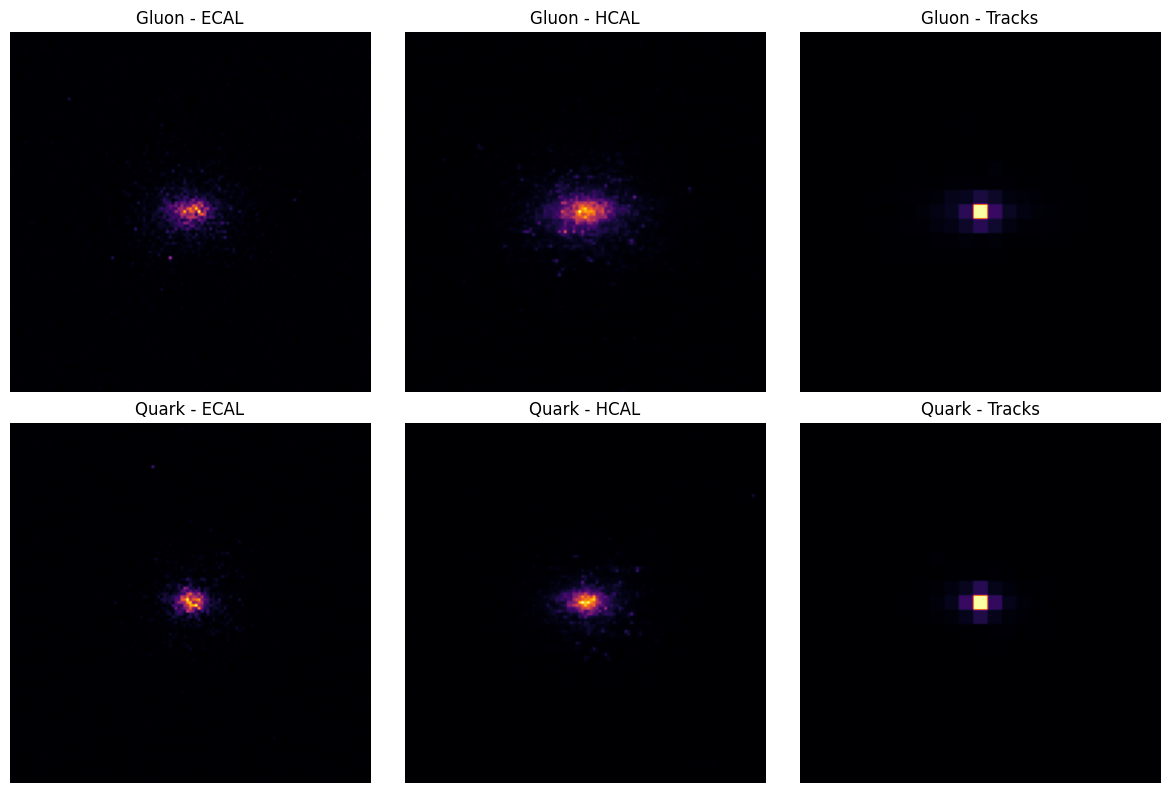

In [39]:
# channel intensity
mean_img_gluon = X[y == 0][:500].mean(axis=0)
mean_img_quark = X[y == 1][:500].mean(axis=0)

channel_names = ['ECAL', 'HCAL', 'Tracks']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ch in range(3):
    axes[0, ch].imshow(mean_img_gluon[:, :, ch], cmap='inferno')
    axes[0, ch].set_title(f"Gluon - {channel_names[ch]}")
    axes[0, ch].axis('off')

    axes[1, ch].imshow(mean_img_quark[:, :, ch], cmap='inferno')
    axes[1, ch].set_title(f"Quark - {channel_names[ch]}")
    axes[1, ch].axis('off')

plt.tight_layout()
plt.show()

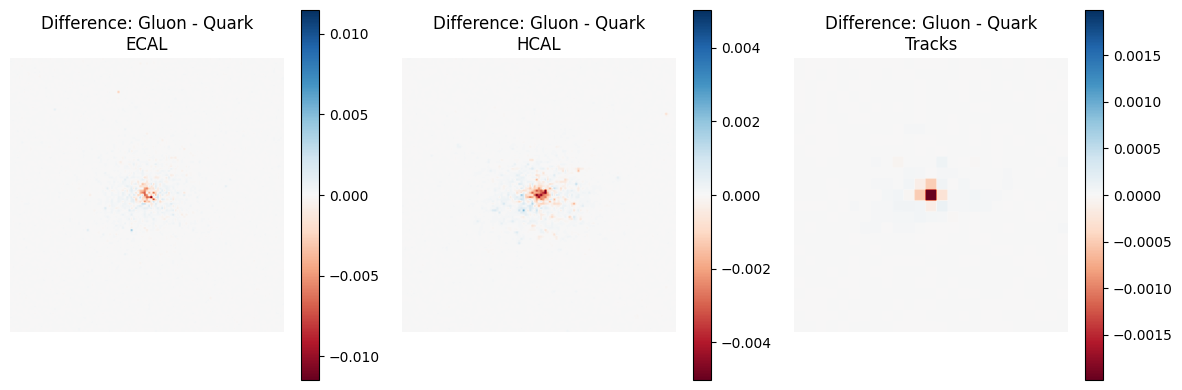

In [43]:
# diff map
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

diff = mean_img_gluon - mean_img_quark

for ch in range(3):
    im = axes[ch].imshow(diff[:, :, ch], cmap="RdBu", vmin=-np.abs(diff[:,:,ch]).max(), vmax=np.abs(diff[:,:,ch]).max())
    axes[ch].set_title(f"Difference: Gluon - Quark\n{channel_names[ch]}")
    axes[ch].axis("off")
    plt.colorbar(im, ax=axes[ch])

plt.tight_layout()
plt.show()

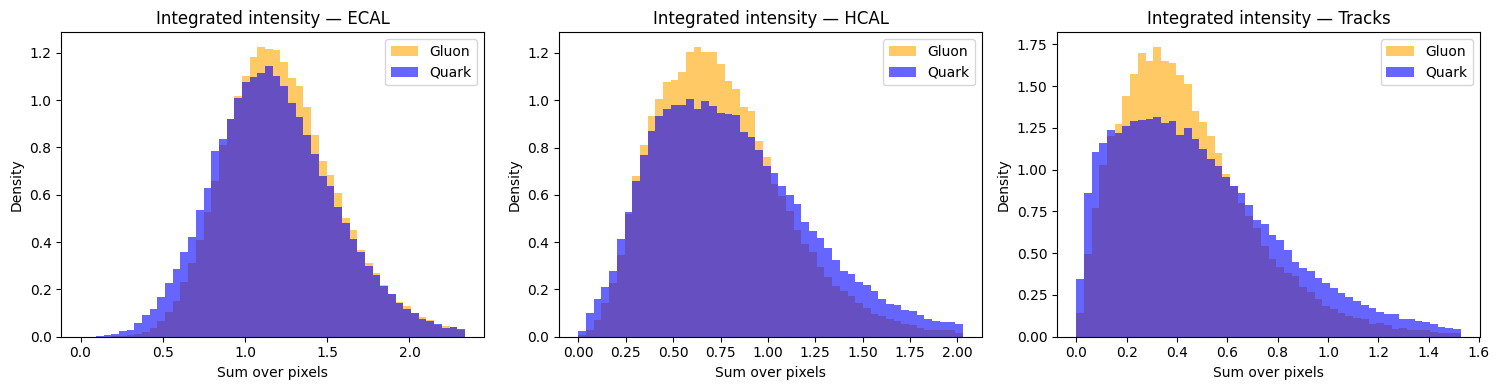

In [49]:
def plot_channel_intensity(X, y):
    channel_sum = X.sum(axis=(1,2))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ch in range(3):
        xmax = np.percentile(channel_sum[:, ch], 99)
        axes[ch].hist(channel_sum[y == 0, ch], bins= 50, alpha= .6, color='orange', density=True, label='Gluon', range=(0, xmax))
        axes[ch].hist(channel_sum[y == 1, ch], bins= 50, alpha= .6, color='blue', density=True, label='Quark', range=(0, xmax))

        axes[ch].set_title(f"Integrated intensity — {channel_names[ch]}")
        axes[ch].set_xlabel("Sum over pixels")
        axes[ch].set_ylabel("Density")
        axes[ch].legend()

    plt.tight_layout()
    plt.show()

plot_channel_intensity(X, y)

In [50]:
# graph construction